<a href="https://colab.research.google.com/github/zhderic/portfolio/blob/main/duffing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задача параметрической идентификации осциллятора Дюффинга по зашумленным измерениям

## 1. Постановка задачи

В лаборатории изучают поведение вибрационной установки. Лабораторная вибрационная установка представляет собой металлический консольный стержень с электромагнитным возбудителем, который возбуждает колебания свободного конца стержня.

По сигналу датчика перемещения получен временной ряд x(t) на интервале 60 секунд. Поскольку экспериментальные данные содержат погрешности измерений, возникает задача параметрической идентификации математической модели, позволяющая по зашумленным измерениям восстановить параметры эталонной динамической системы, порождающей «чистый» сигнал.

При решении считайте, что система описывается уравнением Дюффинга с кубической нелинейностью:

$$ m\ddot{x}(t) + c\dot{x}(t) + k_1 x(t) + k_3 x^3(t) = A \cos(\omega t) \qquad (1) $$

Известно:
- Масса: **m = 4**
- Частота возбуждения: **ω = 1.2**
- Начальные условия: **x(0) = 0.01**, **ẋ(0) = 0**
- Временная сетка: **tᵢ = 0.02 · i**, где **i = 0, 1, …, 3000**
- Количество точек: **N = 3001**
- Общая длительность: **T = 60** секунд

Неизвестные параметры (подлежат идентификации):
$$ c, \quad k_1, \quad k_3, \quad A. $$


**Входные данные**

Файл в формате CSV с двумя столбцами:
- `t` — время
- `x` — измеренное перемещение (содержит шум измерений)

**Выходные данные**

Одна строка из четырёх чисел в следующем порядке:
$$ c \quad k_1 \quad k_3 \quad A $$



## 2. Загрузка и визуализация данных

In [16]:
import numpy as np

dt = 0.02
n_steps = len(t)
m = 4.0
omega = 1.2
x0 = 0.01
v0 = 0.0

data = np.loadtxt('/content/duffing_data_магистры.csv', delimiter=',', skiprows=1)
t = data[:, 0]
x = data[:, 1]

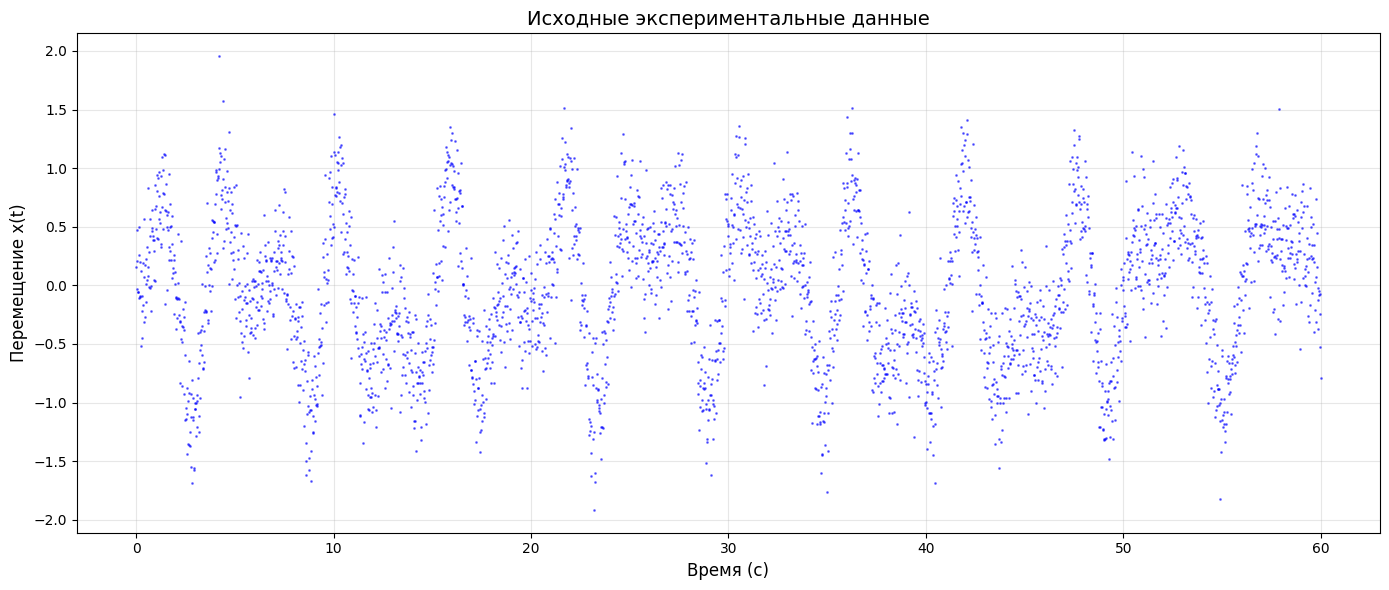

In [4]:
import matplotlib.pyplot as plt

fig2, ax = plt.subplots(figsize=(14, 6))

ax.plot(t, x, 'b.', markersize=2, alpha=0.5)
ax.set_xlabel('Время (с)', fontsize=12)
ax.set_ylabel('Перемещение x(t)', fontsize=12)
ax.set_title('Исходные экспериментальные данные', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Алгебраический метод

Преобразуем дифференциальное уравнение в систему линейных алгебраических уравнений относительно неизвестных параметров, проинтегрировав зашумленные данные. Далее решим полученное СЛАУ методом наименьших квадратов.

In [5]:
from scipy.integrate import cumulative_trapezoid

# Вычисление интегралов
I1 = cumulative_trapezoid(x, t, initial=0)
I2 = cumulative_trapezoid(I1, t, initial=0)

J1 = cumulative_trapezoid(x**3, t, initial=0)
J2 = cumulative_trapezoid(J1, t, initial=0)

# Правая часть (вычеслена аналитически)
F2 = (1 - np.cos(omega * t)) / omega ** 2

# Формирование матрицы
M = np.column_stack([I1 - x0 * t, I2, J2, -F2])
b = m * x0 - m * x

# МНК
p, residuals, rank, s = np.linalg.lstsq(M, b, rcond=None)
c, k1, k3, A = p

In [6]:
print(c.item(), k1.item(), k3.item(), A.item())

0.21586408243249938 0.09767932528960789 -0.06509312540706294 -1.5921424794604742


Численно решим дифференциальное уравнение методом Рунге-Кутты 4-го порядка.

In [7]:
from scipy.integrate import solve_ivp

t_start = 0.0
t_end = 60.0

def duffing_oscillator(t, y):
    """
    Правые части уравнения Дюффинга в форме Коши.

    Параметры:
    t : float - время
    y : array - вектор состояния [x, v]

    Возвращает:
    dydt : array - производные [dx/dt, dv/dt]
    """
    x, v = y
    dxdt = v
    dvdt = (A * np.cos(omega * t) - c * v - k1 * x - k3 * x**3) / m
    return [dxdt, dvdt]

y0 = [x0, v0]

solution = solve_ivp(
    duffing_oscillator,
    (t_start, t_end),
    y0,
    t_eval=t,
    method='RK45',
    rtol=1e-8,
    atol=1e-10
)

x_solution = solution.y[0]
v_solution = solution.y[1]

Визуализируем полученное решение.

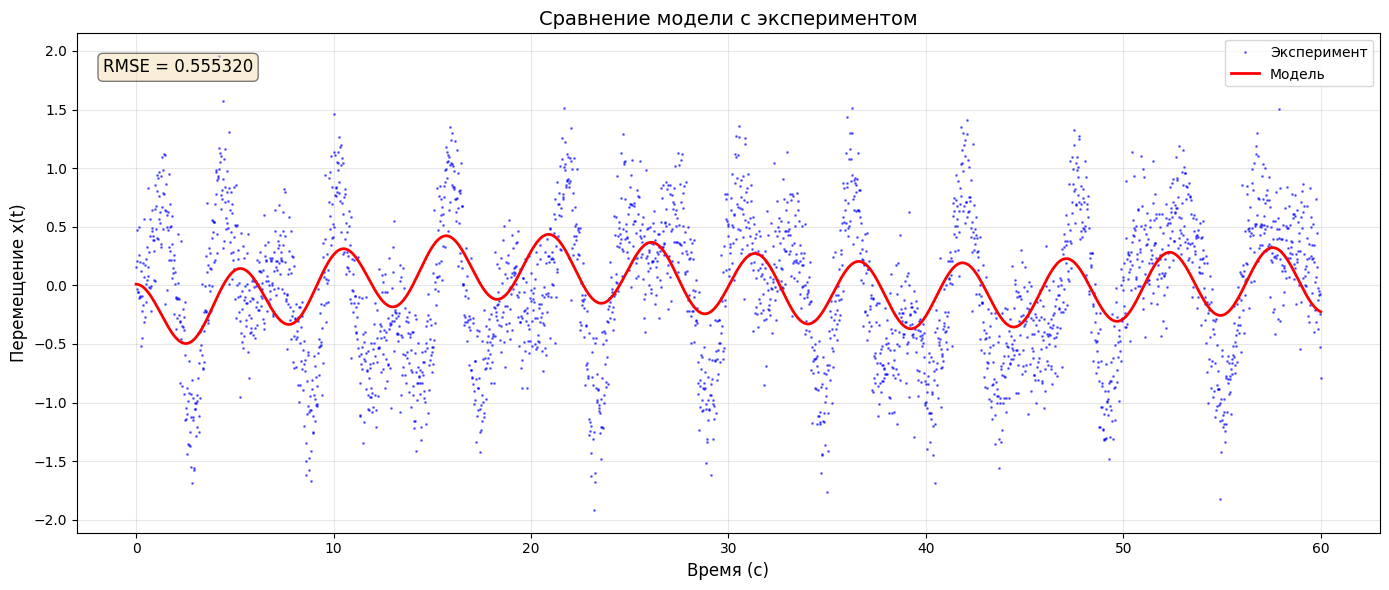

In [8]:
fig2, ax = plt.subplots(figsize=(14, 6))

ax.plot(t, x, 'b.', markersize=2, alpha=0.5, label='Эксперимент')
ax.plot(t, x_solution, 'r-', linewidth=2, label='Модель')

ax.set_xlabel('Время (с)', fontsize=12)
ax.set_ylabel('Перемещение x(t)', fontsize=12)
ax.set_title('Сравнение модели с экспериментом', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

rmse = np.sqrt(np.mean((x - x_solution)**2))

textstr = f'RMSE = {rmse:.6f}'
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

Как видно из графика, полученное решение требует дальнейшей оптимизации. Для этого воспользуемся генетическим алгоритмом.

## 4. Генетический алгоритм

### Установка библиотеки для ГА.

In [9]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.4 MB/s eta 0:00:00


### Блок функций

In [10]:
def solve_duffing_rk4(c, k1, k3, A):
    """
    Решает уравнение Дюффинга методом Рунге-Кутты 4-го порядка
    Возвращает решение на той же сетке, что и экспериментальные данные
    """
    # Инициализация массивов
    x = np.zeros(n_steps)
    v = np.zeros(n_steps)

    # Начальные условия
    x[0] = x0
    v[0] = v0

    # Функция правых частей
    def derivatives(x_val, v_val, t_val):
        dxdt = v_val
        dvdt = (A * np.cos(omega * t_val) - c * v_val - k1 * x_val - k3 * x_val**3) / m
        return dxdt, dvdt

    # Интегрирование методом РК4
    for i in range(n_steps - 1):
        t_current = t[i]
        dx1, dv1 = derivatives(x[i], v[i], t_current)
        dx2, dv2 = derivatives(x[i] + dx1 * dt/2, v[i] + dv1 * dt/2, t_current + dt/2)
        dx3, dv3 = derivatives(x[i] + dx2 * dt/2, v[i] + dv2 * dt/2, t_current + dt/2)
        dx4, dv4 = derivatives(x[i] + dx3 * dt, v[i] + dv3 * dt, t_current + dt)

        x[i+1] = x[i] + (dx1 + 2*dx2 + 2*dx3 + dx4) * dt / 6
        v[i+1] = v[i] + (dv1 + 2*dv2 + 2*dv3 + dv4) * dt / 6

        if np.abs(x[i+1]) > 1e10 or np.isnan(x[i+1]):
            return np.ones(n_steps) * 1e10
    return x

In [11]:
def rmse_fitness(individual):
    """
    Вычисляет среднеквадратичную ошибку между моделью и экспериментом
    individual - список параметров [c, k1, k3, A]
    """
    c, k1, k3, A = individual
    x_model = solve_duffing_rk4(c, k1, k3, A)
    rmse = np.sqrt(np.mean((x - x_model) ** 2))
    return rmse,

In [12]:
def graphics():
    """
    Строит графики на основе базового и полученного решений
    """
    # Получаем решения
    x_best = solve_duffing_rk4(best_c, best_k1, best_k3, best_A)
    x_initial = solve_duffing_rk4(c, k1, k3, A)

    # Создаем фигуру
    fig = plt.figure(figsize=(16, 12))

    # График 1: Сравнение
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(t, x, 'b.', markersize=2, alpha=0.5, label='Эксперимент')
    ax1.plot(t, x_initial, 'g-', linewidth=1.5, alpha=0.7, label='Начальное приближение')
    ax1.plot(t, x_best, 'r-', linewidth=2, label='Оптимизированная модель')
    ax1.set_xlabel('Время (с)', fontsize=12)
    ax1.set_ylabel('Перемещение x(t)', fontsize=12)
    ax1.set_title('Сравнение модели с экспериментом', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')
    ax1.set_xlim([0, 60])

    # График 2: Эволюция ошибки
    ax2 = plt.subplot(3, 1, 2)
    generations = range(len(logbook))
    min_fitness = logbook.select("min")
    avg_fitness = logbook.select("avg")
    ax2.plot(generations, min_fitness, 'b-', linewidth=2, label='Лучшая RMSE')
    ax2.plot(generations, avg_fitness, 'r--', linewidth=2, label='Средняя RMSE')
    ax2.set_xlabel('Поколение', fontsize=12)
    ax2.set_ylabel('RMSE', fontsize=12)
    ax2.set_title('Сходимость генетического алгоритма', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    ax2.set_yscale('log')

    # График 3: Остатки
    ax3 = plt.subplot(3, 1, 3)
    residuals_best = x - x_best
    residuals_init = x - x_initial
    ax3.plot(t, residuals_best, 'r-', linewidth=1, alpha=0.7, label='Остатки (оптимизированная)')
    ax3.plot(t, residuals_init, 'g-', linewidth=1, alpha=0.5, label='Остатки (начальная)')
    ax3.axhline(y=0, color='k', linewidth=0.5, linestyle='--')
    ax3.set_xlabel('Время (с)', fontsize=12)
    ax3.set_ylabel('Остатки', fontsize=12)
    ax3.set_title('Остатки модели', fontsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper right')
    ax3.set_xlim([0, 60])

    plt.tight_layout()
    plt.show()

#### Функция реализующая ГА

Функция, суть которой заключается в том, что она дополняет функцию eaSimple из модуля deap.algoritms, добавляя в неё элитизм, то есть она гарантирует переход одного или нескольких лучших особей (в зависимости от размера зала славы) в следующее поколение, что значительно ускоряет сходимость алгоритма.

In [13]:
from deap.algorithms import varAnd

def eaSimpleElitism(population, toolbox, cxpb, mutpb, ngen, stats=None,
             halloffame=None, verbose=__debug__, callback=None):

    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in population if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    if halloffame is not None:
        halloffame.update(population)

    hof_size = len(halloffame.items) if halloffame.items else 0

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(invalid_ind), **record)
    if verbose:
        print(logbook.stream)

    # Begin the generational process
    for gen in range(1, ngen + 1):
        # Select the next generation individuals
        offspring = toolbox.select(population, len(population) - hof_size)

        # Vary the pool of individuals
        offspring = varAnd(offspring, toolbox, cxpb, mutpb)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        offspring.extend(halloffame.items)

        # Update the hall of fame with the generated individuals
        if halloffame is not None:
            halloffame.update(offspring)

        # Replace the current population by the offspring
        population[:] = offspring

        # Append the current generation statistics to the logbook
        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

        if callback:
            callback[0](*callback[1])

    return population, logbook

### Реализация ГА

#### 1 итерация

Так как имеющееся решение далеко от оптимального, диапозоны поиска, параметры кроссинговера и мутации назначим сравнительно большими, для более широкой области поиска оптимального решения.


Запуск генетического алгоритма...
Начальные параметры:
c = 0.215864
k1 = 0.097679
k3 = -0.065093
A = -1.592142
Начальная RMSE: 0.555320

gen	nevals	min     	avg    
0  	99    	0.553863	4.3e+09
1  	88    	0.553863	1.1e+09
2  	82    	0.545689	1.4e+09
3  	76    	0.534967	1.4e+09
4  	81    	0.534967	1.3e+09
5  	75    	0.534967	8e+08  
6  	79    	0.526777	6e+08  
7  	80    	0.470397	3e+08  
8  	79    	0.470397	3e+08  
9  	82    	0.470397	5e+08  
10 	84    	0.470397	4e+08  
11 	81    	0.467421	6e+08  
12 	83    	0.458179	4e+08  
13 	75    	0.431739	1e+08  
14 	79    	0.431739	3e+08  
15 	89    	0.431739	0.963869
16 	80    	0.428575	1e+08   
17 	84    	0.428575	1e+08   
18 	92    	0.365153	2e+08   
19 	82    	0.365153	2e+08   
20 	79    	0.365153	1e+08   
21 	81    	0.365153	6e+08   
22 	83    	0.365153	1e+08   
23 	73    	0.365153	0.693607
24 	82    	0.365153	0.563841
25 	78    	0.360927	0.817195
26 	74    	0.360927	0.824496
27 	83    	0.360927	0.920073
28 	78    	0.357269	0.90748 
29 	88  

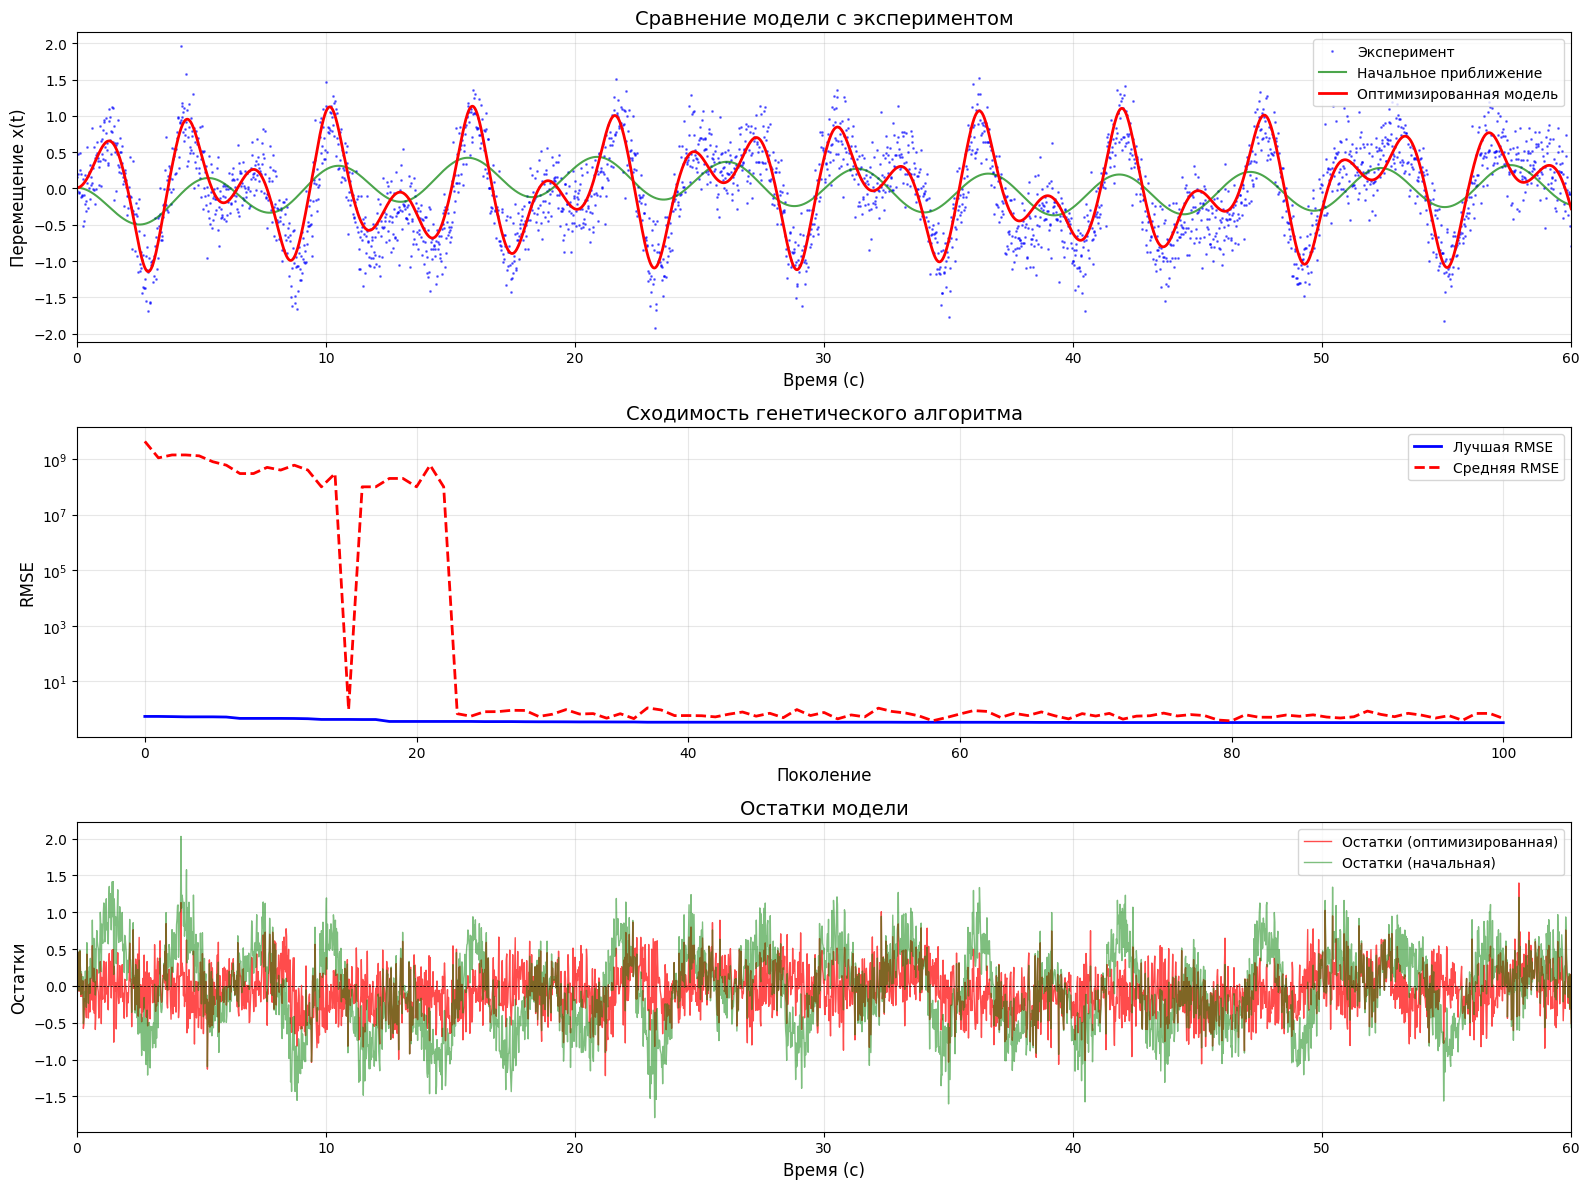

In [17]:
from deap import base, creator, tools, algorithms
import random

# Диапазоны поиска для каждого параметра
BOUNDS = [
    [0, 4*c],
    [k1-5, k1+5],
    [k3-5, k3+5],
    [A-10, A+10]
]

POPULATION_SIZE = 100
P_CROSSOVER = 0.8
P_MUTATION = 0.3
MAX_GENERATION = 100
HALL_OF_FAME_SIZE = 5

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if not hasattr(creator, "FitnessMin"):
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

def create_individual():
    individual = [
        random.uniform(BOUNDS[0][0], BOUNDS[0][1]),
        random.uniform(BOUNDS[1][0], BOUNDS[1][1]),
        random.uniform(BOUNDS[2][0], BOUNDS[2][1]),
        random.uniform(BOUNDS[3][0], BOUNDS[3][1])
    ]
    return individual

toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", rmse_fitness)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxBlend, alpha=1.0)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1.0, indpb=0.25)

# Создаем начальную популяцию
population = toolbox.population(n=POPULATION_SIZE)

# Добавляем начальное приближение
initial_individual = creator.Individual([c, k1, k3, A])
initial_individual.fitness.values = rmse_fitness(initial_individual)
population[0] = initial_individual

# Статистика
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min)
stats.register("avg", np.mean)

# Hall of Fame
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

# Запуск генетического алгоритма
print("\n" + "="*50)
print("Запуск генетического алгоритма...")
print("="*50)
print(f"Начальные параметры:")
print(f"c = {c:.6f}")
print(f"k1 = {k1:.6f}")
print(f"k3 = {k3:.6f}")
print(f"A = {A:.6f}")

initial_fitness = rmse_fitness([c, k1, k3, A])[0]
print(f"Начальная RMSE: {initial_fitness:.6f}")
print("="*50 + "\n")

# Запускаем эволюцию
population, logbook = eaSimpleElitism(
    population,
    toolbox,
    cxpb=P_CROSSOVER,
    mutpb=P_MUTATION,
    ngen=MAX_GENERATION,
    stats=stats,
    halloffame=hof,
    verbose=True
)

# Анализ результатов
best_individual = hof[0]
best_fitness = best_individual.fitness.values[0]
best_c, best_k1, best_k3, best_A = best_individual

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ:")
print("="*50)
print(f"Лучшие найденные параметры:")
print(f"c = {best_c:.10f}")
print(f"k1 = {best_k1:.10f}")
print(f"k3 = {best_k3:.10f}")
print(f"A = {best_A:.10f}")
print(f"RMSE = {best_fitness:.10f}")
print(f"Улучшение: {initial_fitness/best_fitness:.2f} раз")
print("="*50)


graphics()

#### 2 итерация

Судя по графику, наше решение сравнительно близко к оптимальному, а это значит, что для более тонкой оптимизации диапозоны поиска, параметры кроссинговера и мутации следует назначить сравнительно небольшими.


Запуск генетического алгоритма...
Начальные параметры:
c = 0.030546
k1 = 10.304447
k3 = 12.283154
A = 6.642258
Начальная RMSE: 0.330570

gen	nevals	min    	avg     
0  	97    	0.33057	0.641247
1  	86    	0.33057	0.930833
2  	89    	0.323796	0.730466
3  	82    	0.323796	0.777598
4  	88    	0.323796	0.613229
5  	86    	0.323796	0.647195
6  	90    	0.323796	0.56711 
7  	85    	0.323796	0.659307
8  	88    	0.323796	0.596716
9  	87    	0.323796	0.499848
10 	79    	0.323796	0.462953
11 	90    	0.323108	0.482924
12 	86    	0.323108	0.627113
13 	76    	0.32264 	0.773775
14 	87    	0.322534	0.597829
15 	89    	0.322428	0.626292
16 	85    	0.322375	0.431409
17 	79    	0.321833	0.44982 
18 	84    	0.321093	0.626251
19 	86    	0.321093	0.652397
20 	77    	0.320887	0.496762
21 	86    	0.320887	0.645501
22 	89    	0.319584	0.45905 
23 	87    	0.319584	0.678578
24 	80    	0.319584	0.675819
25 	76    	0.319584	0.692833
26 	83    	0.319584	0.688761
27 	81    	0.319584	0.569752
28 	84    	0.319584	0.54

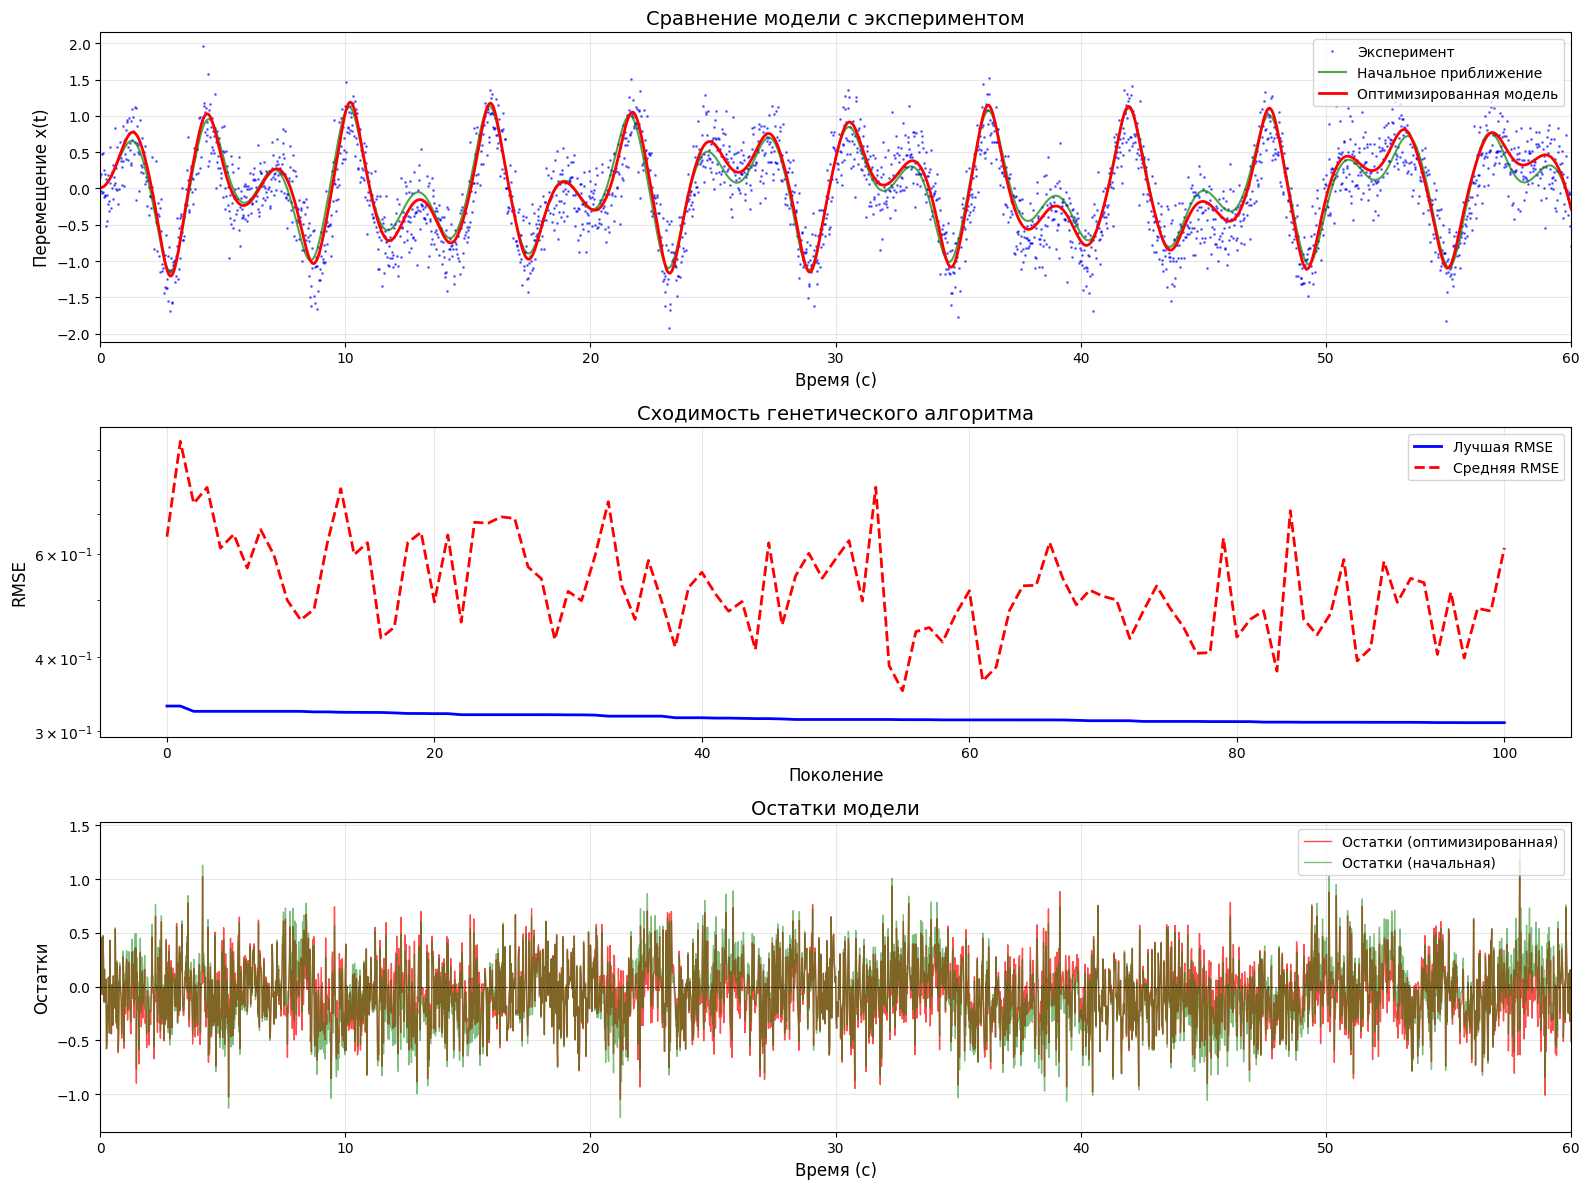

In [18]:
c, k1, k3, A = hof.items[0]

BOUNDS = [
    [0.5 * c, 1.5 * c],
    [0.5 * k1, 1.5 * k1],
    [0.5 * k3, 1.5 * k3],
    [0.5 * A, 1.5 * A]
]

POPULATION_SIZE = 100
P_CROSSOVER = 0.8
P_MUTATION = 0.3
MAX_GENERATION = 100
HALL_OF_FAME_SIZE = 3

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# Функция для создания случайной особи
def create_individual():
    individual = [
        random.uniform(BOUNDS[0][0], BOUNDS[0][1]),
        random.uniform(BOUNDS[1][0], BOUNDS[1][1]),
        random.uniform(BOUNDS[2][0], BOUNDS[2][1]),
        random.uniform(BOUNDS[3][0], BOUNDS[3][1])
    ]
    return individual

toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", rmse_fitness)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.5, indpb=0.5)

# Создаем начальную популяцию
population = toolbox.population(n=POPULATION_SIZE)

# Добавляем начальное приближение
population[0:HALL_OF_FAME_SIZE] = hof.items[0:HALL_OF_FAME_SIZE]
initial_individual = creator.Individual([c, k1, k3, A])
initial_individual.fitness.values = rmse_fitness(initial_individual)

# Статистика
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min)
stats.register("avg", np.mean)

# Hall of Fame
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

# Запуск генетического алгоритма
print("\n" + "="*50)
print("Запуск генетического алгоритма...")
print("="*50)
print(f"Начальные параметры:")
print(f"c = {c:.6f}")
print(f"k1 = {k1:.6f}")
print(f"k3 = {k3:.6f}")
print(f"A = {A:.6f}")

initial_fitness = rmse_fitness([c, k1, k3, A])[0]
print(f"Начальная RMSE: {initial_fitness:.6f}")
print("="*50 + "\n")

# Запускаем эволюцию
population, logbook = eaSimpleElitism(
    population,
    toolbox,
    cxpb=P_CROSSOVER,
    mutpb=P_MUTATION,
    ngen=MAX_GENERATION,
    stats=stats,
    halloffame=hof,
    verbose=True
)

# Анализ результатов
best_individual = hof[0]
best_fitness = best_individual.fitness.values[0]
best_c, best_k1, best_k3, best_A = best_individual

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ:")
print("="*50)
print(f"Лучшие найденные параметры:")
print(f"c = {best_c:.10f}")
print(f"k1 = {best_k1:.10f}")
print(f"k3 = {best_k3:.10f}")
print(f"A = {best_A:.10f}")
print(f"RMSE = {best_fitness:.10f}")
print(f"Улучшение: {initial_fitness/best_fitness:.2f} раз")
print("="*50)

graphics()

#### 3 итерация

Ещё уменьшим диапозон параметров, кроссинговер и мутацию.


Запуск генетического алгоритма...
Начальные параметры:
c = 0.072888
k1 = 3.648770
k3 = 22.252963
A = 6.139258
Начальная RMSE: 0.305856

gen	nevals	min     	avg     
0  	97    	0.305856	0.575297
1  	90    	0.305856	0.497101
2  	86    	0.305856	0.404355
3  	87    	0.305833	0.353127
4  	86    	0.305833	0.335365
5  	91    	0.305833	0.317068
6  	91    	0.305826	0.313882
7  	84    	0.305819	0.309578
8  	82    	0.305753	0.308436
9  	81    	0.305689	0.307867
10 	88    	0.305689	0.307478
11 	82    	0.305667	0.306986
12 	87    	0.305667	0.307326
13 	78    	0.305657	0.30722 
14 	91    	0.305656	0.306983
15 	88    	0.305656	0.307084
16 	83    	0.305574	0.306504
17 	80    	0.305574	0.306771
18 	79    	0.305574	0.306685
19 	80    	0.305574	0.306796
20 	87    	0.305574	0.306362
21 	78    	0.305574	0.30686 
22 	87    	0.305574	0.30653 
23 	83    	0.305567	0.306647
24 	84    	0.305563	0.307628
25 	87    	0.305557	0.307458
26 	85    	0.305555	0.307209
27 	86    	0.305555	0.307703
28 	84    	0.305554	0.

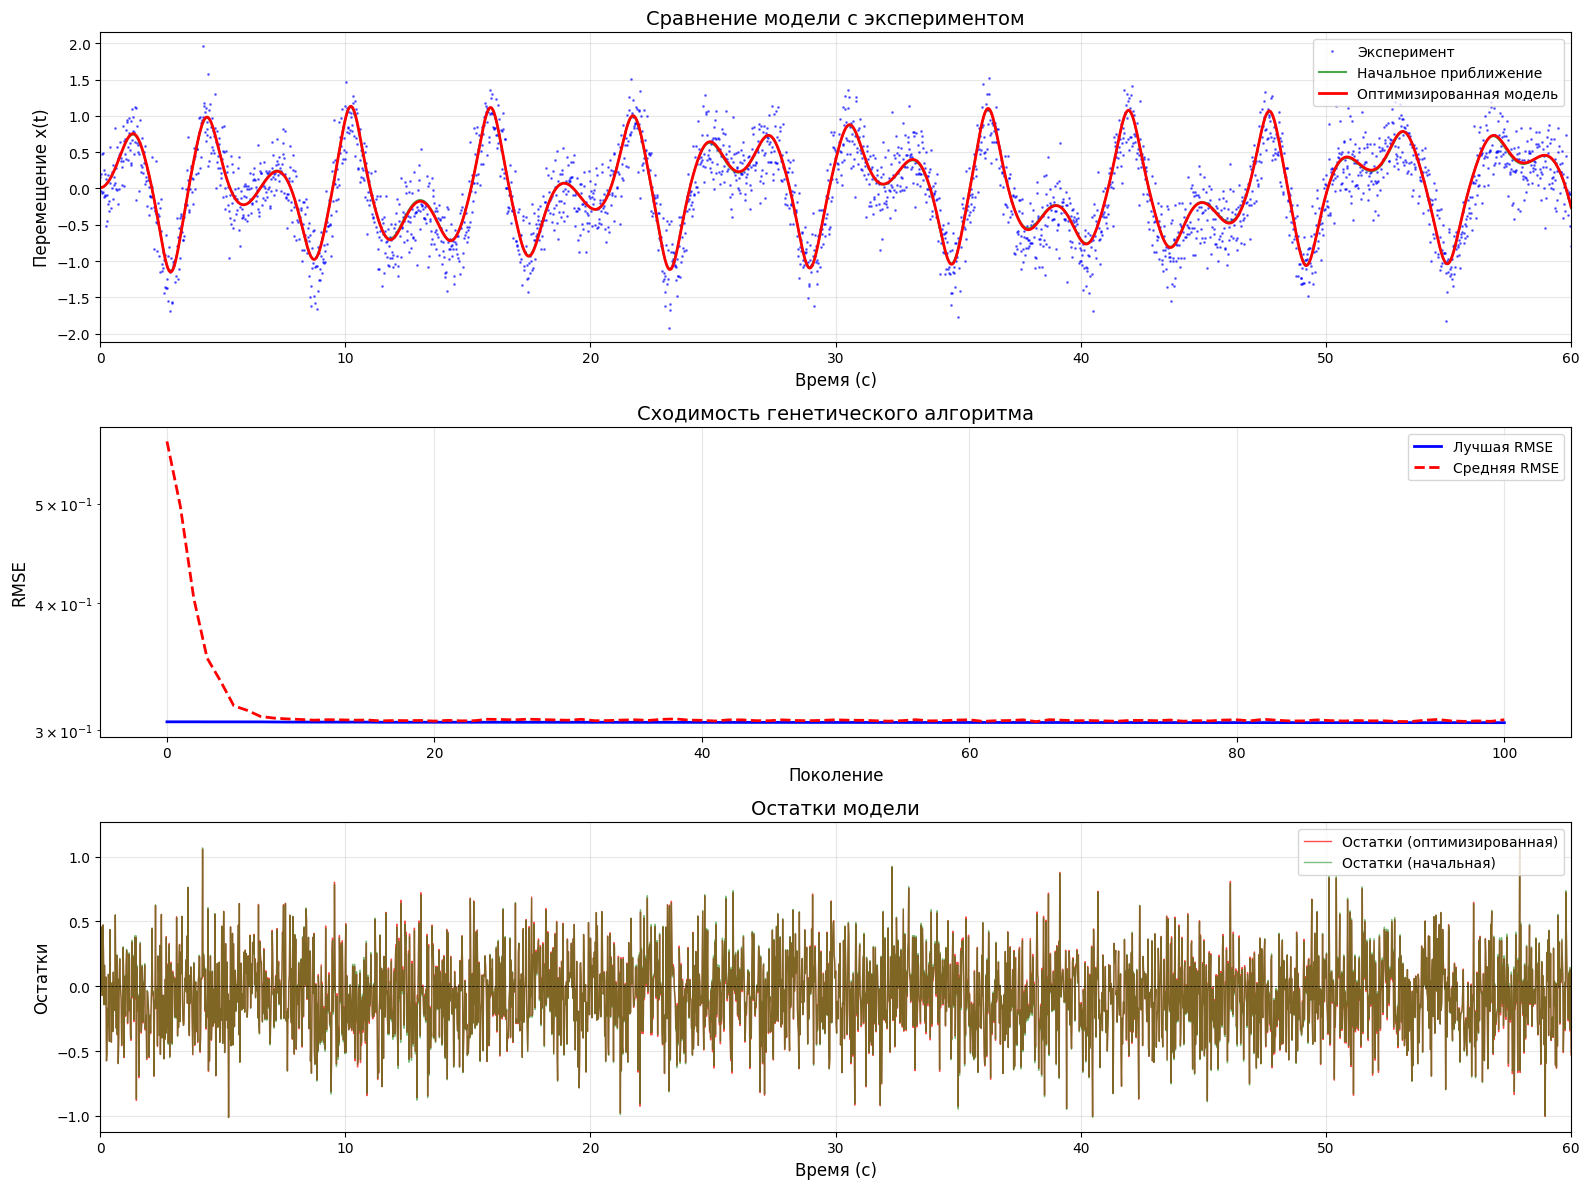

In [21]:
c, k1, k3, A = hof.items[0]

BOUNDS = [
    [0.8 * c, 1.2 * c],
    [0.8 * k1, 1.2 * k1],
    [0.8 * k3, 1.2 * k3],
    [0.8 * A, 1.2 * A]
]

POPULATION_SIZE = 100
P_CROSSOVER = 0.8
P_MUTATION = 0.4
MAX_GENERATION = 100
HALL_OF_FAME_SIZE = 3

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Функция для создания случайной особи
def create_individual():
    individual = [
        random.uniform(BOUNDS[0][0], BOUNDS[0][1]),
        random.uniform(BOUNDS[1][0], BOUNDS[1][1]),
        random.uniform(BOUNDS[2][0], BOUNDS[2][1]),
        random.uniform(BOUNDS[3][0], BOUNDS[3][1])
    ]
    return individual

toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", rmse_fitness)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.025, indpb=0.6)

# Создаем начальную популяцию
population = toolbox.population(n=POPULATION_SIZE)

# Добавляем начальное приближение
population[0:HALL_OF_FAME_SIZE] = hof.items[0:HALL_OF_FAME_SIZE]
initial_individual = creator.Individual([c, k1, k3, A])
initial_individual.fitness.values = rmse_fitness(initial_individual)

# Статистика
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min)
stats.register("avg", np.mean)

# Hall of Fame
hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

# Запуск генетического алгоритма
print("\n" + "="*50)
print("Запуск генетического алгоритма...")
print("="*50)
print(f"Начальные параметры:")
print(f"c = {c:.6f}")
print(f"k1 = {k1:.6f}")
print(f"k3 = {k3:.6f}")
print(f"A = {A:.6f}")

initial_fitness = rmse_fitness([c, k1, k3, A])[0]
print(f"Начальная RMSE: {initial_fitness:.6f}")
print("="*50 + "\n")

# Запускаем эволюцию
population, logbook = eaSimpleElitism(
    population,
    toolbox,
    cxpb=P_CROSSOVER,
    mutpb=P_MUTATION,
    ngen=MAX_GENERATION,
    stats=stats,
    halloffame=hof,
    verbose=True
)

# Анализ результатов
best_individual = hof[0]
best_fitness = best_individual.fitness.values[0]
best_c, best_k1, best_k3, best_A = best_individual

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ:")
print("="*50)
print(f"Лучшие найденные параметры:")
print(f"c = {best_c:.10f}")
print(f"k1 = {best_k1:.10f}")
print(f"k3 = {best_k3:.10f}")
print(f"A = {best_A:.10f}")
print(f"RMSE = {best_fitness:.10f}")
print(f"Улучшение: {initial_fitness/best_fitness:.2f} раз")
print("="*50)

graphics()

## 5. Выводы

In [25]:
c, k1, k3, A = hof.items[0]
print(c, k1, k3, A) # ответ на поставленную задачу

0.07856240801439544 3.1662396641370636 22.512175403021175 6.158695894249107


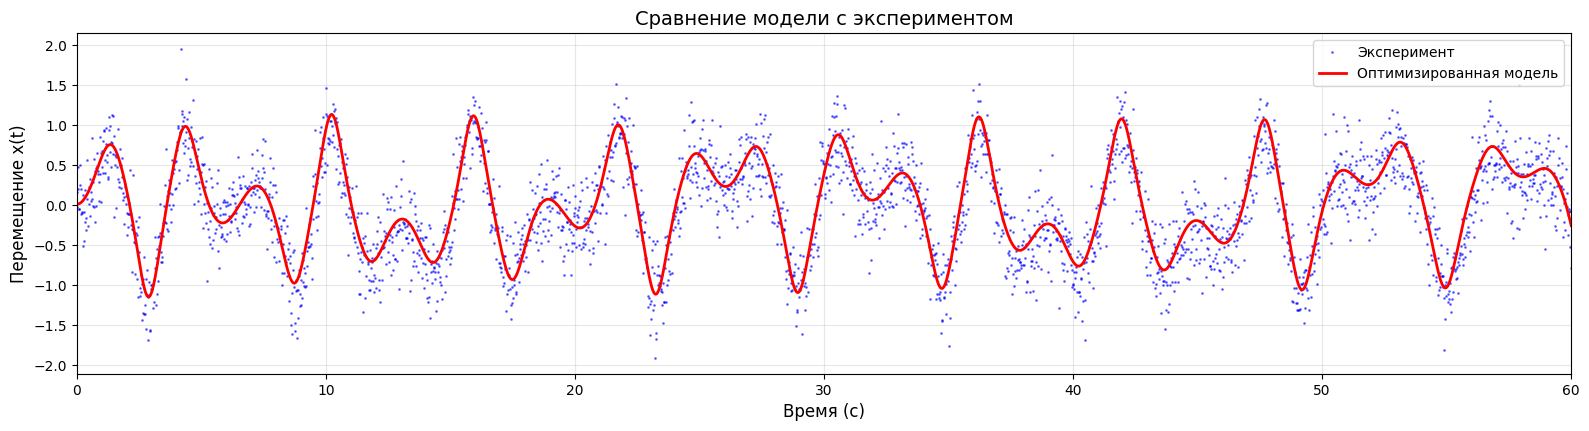

In [28]:
x_best = solve_duffing_rk4(c, k1, k3, A)

fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(3, 1, 1)
ax1.plot(t, x, 'b.', markersize=2, alpha=0.5, label='Эксперимент')
ax1.plot(t, x_best, 'r-', linewidth=2, label='Оптимизированная модель')
ax1.set_xlabel('Время (с)', fontsize=12)
ax1.set_ylabel('Перемещение x(t)', fontsize=12)
ax1.set_title('Сравнение модели с экспериментом', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_xlim([0, 60])

plt.tight_layout()
plt.show()